<a href="https://colab.research.google.com/github/Maahira0810/AIDriven-Archaeological-Site-Mapping/blob/main/Soil_Detection_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install and Import Dependencies

In [ ]:
!pip install -q roboflow ultralytics opencv-python matplotlib seaborn pandas scikit-learn pillow

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import json
from sklearn.metrics import confusion_matrix, jaccard_score, f1_score
from collections import Counter
import yaml
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 129.5 MB/s eta 0:00:00


Download Dataset from Roboflow

In [ ]:
from roboflow import Roboflow

print("Downloading Soil Detection Dataset...")
rf = Roboflow(api_key="MMFZWHhSvylkZHBxlS7M")
project = rf.workspace("imit-h5ows").project("soil-detection-l0ngo")
version = project.version(3)
dataset = version.download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Soil-detection-3 in yolov8:: 100%|██████████| 582/582 [00:00<00:00, 6358.15it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/Soil-detection-3


In [ ]:
# Diagnostic: List all files in dataset directory
print("\n=== Dataset Directory Contents ===")
from pathlib import Path
dataset_path = Path(dataset.location)

# Show first 3 levels of directory structure
print("\nDirectory Tree:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(str(dataset_path), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # Only show first 3 levels
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more files")
    if level >= 2:
        break

# Check for common directory structures
print("\n=== Searching for Image Directories ===")
image_dirs = list(dataset_path.rglob('*images*'))
label_dirs = list(dataset_path.rglob('*labels*'))

print(f"Found {len(image_dirs)} directories with 'images' in name:")
for img_dir in image_dirs[:10]:
    img_count = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png'))) + len(list(img_dir.glob('*.jpeg')))
    print(f"  {img_dir.relative_to(dataset_path)}: {img_count} images")

print(f"\nFound {len(label_dirs)} directories with 'labels' in name:")
for lbl_dir in label_dirs[:10]:
    lbl_count = len(list(lbl_dir.glob('*.txt')))
    print(f"  {lbl_dir.relative_to(dataset_path)}: {lbl_count} labels")


=== Dataset Directory Contents ===

Directory Tree:
Soil-detection-3/
  README.dataset.txt
  data.yaml
  README.roboflow.txt
  train/
    labels/
      golden-crack-earth-dry-ground-260nw-532903036_jpg.rf.d6eb436170f34766d5edd39881171fc3.txt
      peat-moss-isolaetd-on-white-260nw-1935587986_jpg.rf.954743110eb5883f0b3afab099723f47.txt
      Red_9_jpg.rf.1daf58bd8f2f3c9b7ce51a3c66e305d2.txt
      black-sand-texture-dark-soil-260nw-430890610_jpg.rf.e91e003f901834f42f05e2d61f974123.txt
      Copy-of-kalimitti2_jpg.rf.6630c06040d484483f5cf0df14fd26a5.txt
      ... and 194 more files

=== Searching for Image Directories ===
Found 45 directories with 'images' in name:
  train/images: 199 images
  valid/images: 58 images
  test/images: 28 images
  train/labels/Copy-of-images72-1-_jpg.rf.4e96bd3b5cf0440b2b3f24cfc6dead1f.txt: 0 images
  train/labels/Copy-of-images350_jpg.rf.076a73f0ef90eac3a98809ed3e321bfd.txt: 0 images
  train/labels/Copy-of-images437-1-_jpg.rf.6cfa1a4964bb33e9e80642210770241

Load Dataset Configuration

In [ ]:
with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset Configuration:")
print(f"Number of classes: {data_config['nc']}")
print(f"Class names: {data_config['names']}")

# Fix dataset paths - Roboflow often uses relative paths
dataset_root = Path(dataset.location)

# Check and fix train path
if 'train' in data_config:
    train_path_original = data_config['train']
    # Try different path combinations
    possible_train_paths = [
        dataset_root / 'train',
        dataset_root / train_path_original,
        Path(train_path_original)
    ]
    for path in possible_train_paths:
        if path.exists():
            data_config['train'] = str(path)
            break

# Check and fix val path
if 'val' in data_config:
    val_path_original = data_config['val']
    possible_val_paths = [
        dataset_root / 'valid',
        dataset_root / 'val',
        dataset_root / val_path_original,
        Path(val_path_original)
    ]
    for path in possible_val_paths:
        if path.exists():
            data_config['val'] = str(path)
            break

# If paths still don't exist, search for images folder
if not Path(data_config.get('train', '')).exists():
    # Search for train/images folder
    train_imgs = list(dataset_root.rglob('train/images'))
    if not train_imgs:
        train_imgs = list(dataset_root.rglob('*/images'))
    if train_imgs:
        data_config['train'] = str(train_imgs[0].parent)

if not Path(data_config.get('val', '')).exists():
    # Search for valid/images folder
    val_imgs = list(dataset_root.rglob('valid/images'))
    if not val_imgs:
        val_imgs = list(dataset_root.rglob('val/images'))
    if val_imgs:
        data_config['val'] = str(val_imgs[0].parent)

print(f"Train path: {data_config['train']}")
print(f"Valid path: {data_config['val']}")
print(f"Test path: {data_config.get('test', 'Not available')}")

# Verify paths exist
train_exists = Path(data_config['train']).exists() if 'train' in data_config else False
val_exists = Path(data_config['val']).exists() if 'val' in data_config else False

print(f"\nPath Verification:")
print(f"Train path exists: {train_exists}")
print(f"Val path exists: {val_exists}")

# Define soil types
SOIL_CLASSES = data_config['names']
print(f"\nSoil Types in Dataset: {SOIL_CLASSES}")

# Update YAML file with corrected paths
corrected_yaml_path = dataset_root / 'data_corrected.yaml'
with open(corrected_yaml_path, 'w') as f:
    yaml.dump(data_config, f)
print(f"\nCorrected YAML saved to: {corrected_yaml_path}")

Dataset Configuration:
Number of classes: 4
Class names: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']
Train path: /content/Soil-detection-3/train
Valid path: /content/Soil-detection-3/valid
Test path: ../test/images

Path Verification:
Train path exists: True
Val path exists: True

Soil Types in Dataset: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']

Corrected YAML saved to: /content/Soil-detection-3/data_corrected.yaml


Exploratory Data Analysis - Dataset Statistics


=== Exploring Dataset Structure ===
Dataset root: /content/Soil-detection-3

Directory structure:
  train/  (2 items)
  valid/  (2 items)
  test/  (2 items)
  train/labels/  (199 items)
  train/images/  (199 items)
  valid/labels/  (58 items)
  valid/images/  (58 items)
  test/labels/  (28 items)
  test/images/  (28 items)

=== Dataset Statistics ===
Found 199 images in /content/Soil-detection-3/train/images
Found 199 labels in /content/Soil-detection-3/train/labels
Found 58 images in /content/Soil-detection-3/valid/images
Found 58 labels in /content/Soil-detection-3/valid/labels

Training Set: 199 images, 199 labels
Validation Set: 58 images, 58 labels


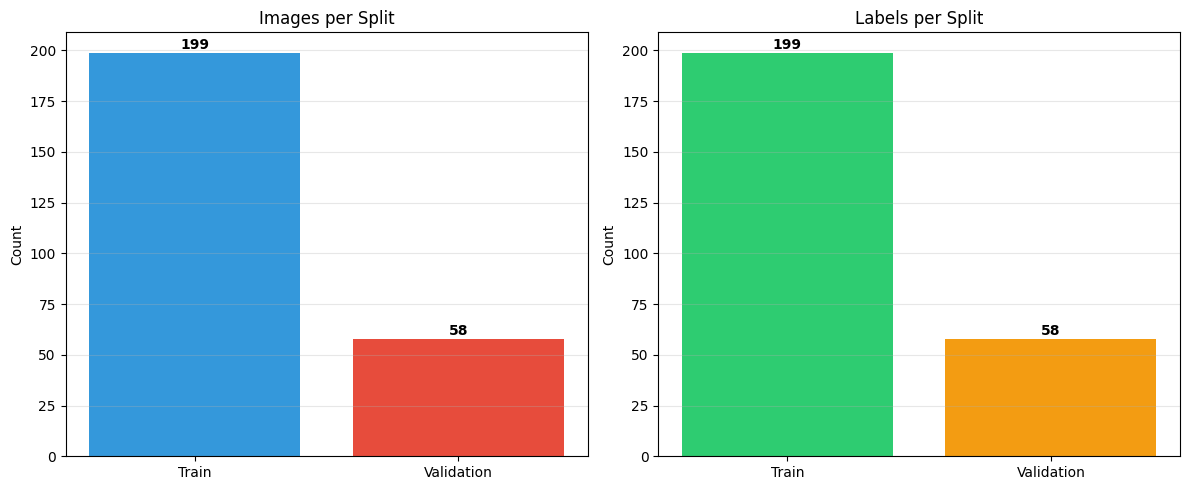

In [ ]:
def count_images_and_labels(data_path):
    """Count images and labels in dataset split"""
    data_path = Path(data_path)

    # Check if path exists
    if not data_path.exists():
        print(f"Warning: Path does not exist: {data_path}")
        return 0, 0

    img_path = data_path / 'images'
    lbl_path = data_path / 'labels'

    # Create paths if they don't exist
    if not img_path.exists():
        print(f"Warning: Image path does not exist: {img_path}")
        # Try alternative structure
        if (data_path.parent / 'images').exists():
            img_path = data_path.parent / 'images'
        else:
            return 0, 0

    if not lbl_path.exists():
        print(f"Warning: Label path does not exist: {lbl_path}")
        # Try alternative structure
        if (data_path.parent / 'labels').exists():
            lbl_path = data_path.parent / 'labels'
        else:
            lbl_path = img_path.parent / 'labels'

    images = list(img_path.glob('*.jpg')) + list(img_path.glob('*.png')) + list(img_path.glob('*.jpeg'))
    labels = list(lbl_path.glob('*.txt'))

    print(f"Found {len(images)} images in {img_path}")
    print(f"Found {len(labels)} labels in {lbl_path}")

    return len(images), len(labels)

# Let's also explore the dataset structure
print("\n=== Exploring Dataset Structure ===")
dataset_root = Path(dataset.location)
print(f"Dataset root: {dataset_root}")
print("\nDirectory structure:")
for item in dataset_root.rglob('*'):
    if item.is_dir():
        num_files = len(list(item.iterdir()))
        print(f"  {item.relative_to(dataset_root)}/  ({num_files} items)")

# Count for each split
print("\n=== Dataset Statistics ===")
train_imgs, train_lbls = count_images_and_labels(data_config['train'])
val_imgs, val_lbls = count_images_and_labels(data_config['val'])

print(f"\nTraining Set: {train_imgs} images, {train_lbls} labels")
print(f"Validation Set: {val_imgs} images, {val_lbls} labels")

# Only create visualization if we have data
if train_imgs > 0 or val_imgs > 0:
    # Visualize dataset split
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    splits = ['Train', 'Validation']
    img_counts = [train_imgs, val_imgs]
    lbl_counts = [train_lbls, val_lbls]

    ax[0].bar(splits, img_counts, color=['#3498db', '#e74c3c'])
    ax[0].set_ylabel('Count')
    ax[0].set_title('Images per Split')
    ax[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(img_counts):
        ax[0].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

    ax[1].bar(splits, lbl_counts, color=['#2ecc71', '#f39c12'])
    ax[1].set_ylabel('Count')
    ax[1].set_title('Labels per Split')
    ax[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(lbl_counts):
        ax[1].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig('dataset_split_stats.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n⚠️ WARNING: No images found! Please check:")
    print("1. Dataset downloaded correctly")
    print("2. File paths are correct")
    print(f"3. Expected structure: {dataset_root}/train/images/ and {dataset_root}/train/labels/")
    print(f"   OR: {dataset_root}/valid/images/ and {dataset_root}/valid/labels/")

EDA - Class Distribution Analysis


=== Class Distribution (Training Set) ===
Alluvial Soil: 78 instances (32.10%)
Black Soil: 60 instances (24.69%)
Clay Soil: 30 instances (12.35%)
Red Soil: 75 instances (30.86%)


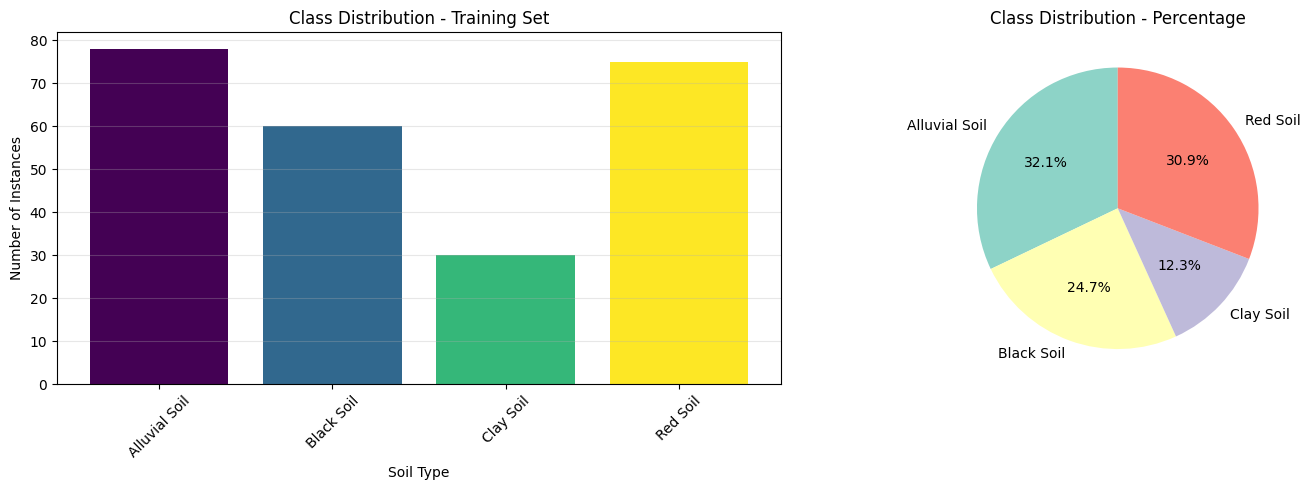

In [ ]:
def analyze_class_distribution(labels_path, class_names):
    """Analyze distribution of classes in labels"""
    class_counts = Counter()
    total_objects = 0

    label_files = list(Path(labels_path).glob('*.txt'))

    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1
                    total_objects += 1

    return class_counts, total_objects

# Analyze training set
train_lbl_path = Path(data_config['train']) / 'labels'
class_counts, total_objs = analyze_class_distribution(train_lbl_path, SOIL_CLASSES)

print("\n=== Class Distribution (Training Set) ===")
class_data = []
for class_id, count in sorted(class_counts.items()):
    percentage = (count / total_objs) * 100
    class_name = SOIL_CLASSES[class_id]
    print(f"{class_name}: {count} instances ({percentage:.2f}%)")
    class_data.append({'Class': class_name, 'Count': count, 'Percentage': percentage})

df_classes = pd.DataFrame(class_data)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
axes[0].bar(df_classes['Class'], df_classes['Count'], color=plt.cm.viridis(np.linspace(0, 1, len(df_classes))))
axes[0].set_xlabel('Soil Type')
axes[0].set_ylabel('Number of Instances')
axes[0].set_title('Class Distribution - Training Set')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = plt.cm.Set3(range(len(df_classes)))
axes[1].pie(df_classes['Count'], labels=df_classes['Class'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution - Percentage')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

EDA - Image Size Analysis

Analyzing 199 images from /content/Soil-detection-3/train/images

=== Image Dimensions Analysis ===
Images analyzed: 199
Unique dimensions found: 1

All unique sizes:
  640x640: 199 images (100.0%)

Statistics:
Average Width: 640.00 px
Average Height: 640.00 px
Width Range: 640 - 640 px
Height Range: 640 - 640 px
Standard Deviation - Width: 0.00 px
Standard Deviation - Height: 0.00 px

⚠️ NOTE: All images are exactly the same size (640x640)
This is likely because Roboflow preprocessed the dataset to a uniform size.
This is actually GOOD for training as YOLOv8 requires consistent input sizes!


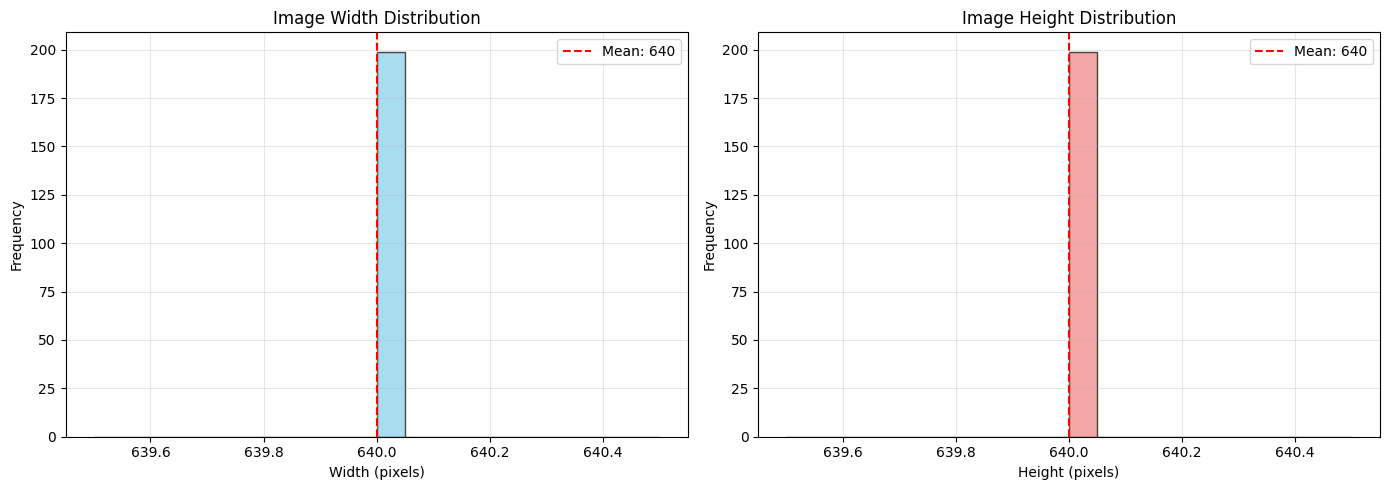

In [ ]:
def analyze_image_sizes(image_path):
    """Analyze dimensions of images"""
    sizes = []
    unique_sizes = set()
    img_files = list(Path(image_path).glob('*.jpg')) + list(Path(image_path).glob('*.png')) + list(Path(image_path).glob('*.jpeg'))

    print(f"Analyzing {len(img_files)} images from {image_path}")

    # Sample more images to get better statistics
    sample_size = min(len(img_files), 200)
    sample_files = np.random.choice(img_files, sample_size, replace=False) if len(img_files) > sample_size else img_files

    for img_file in sample_files:
        try:
            img = Image.open(img_file)
            sizes.append(img.size)
            unique_sizes.add(img.size)
        except Exception as e:
            print(f"Error reading {img_file}: {e}")

    return sizes, unique_sizes

train_img_path = Path(data_config['train']) / 'images'
if not train_img_path.exists():
    train_img_path = Path(data_config['train'])

image_sizes, unique_sizes = analyze_image_sizes(train_img_path)

if len(image_sizes) == 0:
    print("⚠️ No images found for dimension analysis!")
else:
    widths = [s[0] for s in image_sizes]
    heights = [s[1] for s in image_sizes]

    print(f"\n=== Image Dimensions Analysis ===")
    print(f"Images analyzed: {len(image_sizes)}")
    print(f"Unique dimensions found: {len(unique_sizes)}")

    if len(unique_sizes) <= 5:
        print(f"\nAll unique sizes:")
        for size in unique_sizes:
            count = image_sizes.count(size)
            print(f"  {size[0]}x{size[1]}: {count} images ({count/len(image_sizes)*100:.1f}%)")

    print(f"\nStatistics:")
    print(f"Average Width: {np.mean(widths):.2f} px")
    print(f"Average Height: {np.mean(heights):.2f} px")
    print(f"Width Range: {min(widths)} - {max(widths)} px")
    print(f"Height Range: {min(heights)} - {max(heights)} px")
    print(f"Standard Deviation - Width: {np.std(widths):.2f} px")
    print(f"Standard Deviation - Height: {np.std(heights):.2f} px")

    # Check if all images are the same size
    if len(unique_sizes) == 1:
        print(f"\n⚠️ NOTE: All images are exactly the same size ({list(unique_sizes)[0][0]}x{list(unique_sizes)[0][1]})")
        print("This is likely because Roboflow preprocessed the dataset to a uniform size.")
        print("This is actually GOOD for training as YOLOv8 requires consistent input sizes!")

# Visualize image dimensions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Image Width Distribution')
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(heights, bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Image Height Distribution')
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

Visualize Sample Images with Annotations


=== Sample Images with Annotations ===


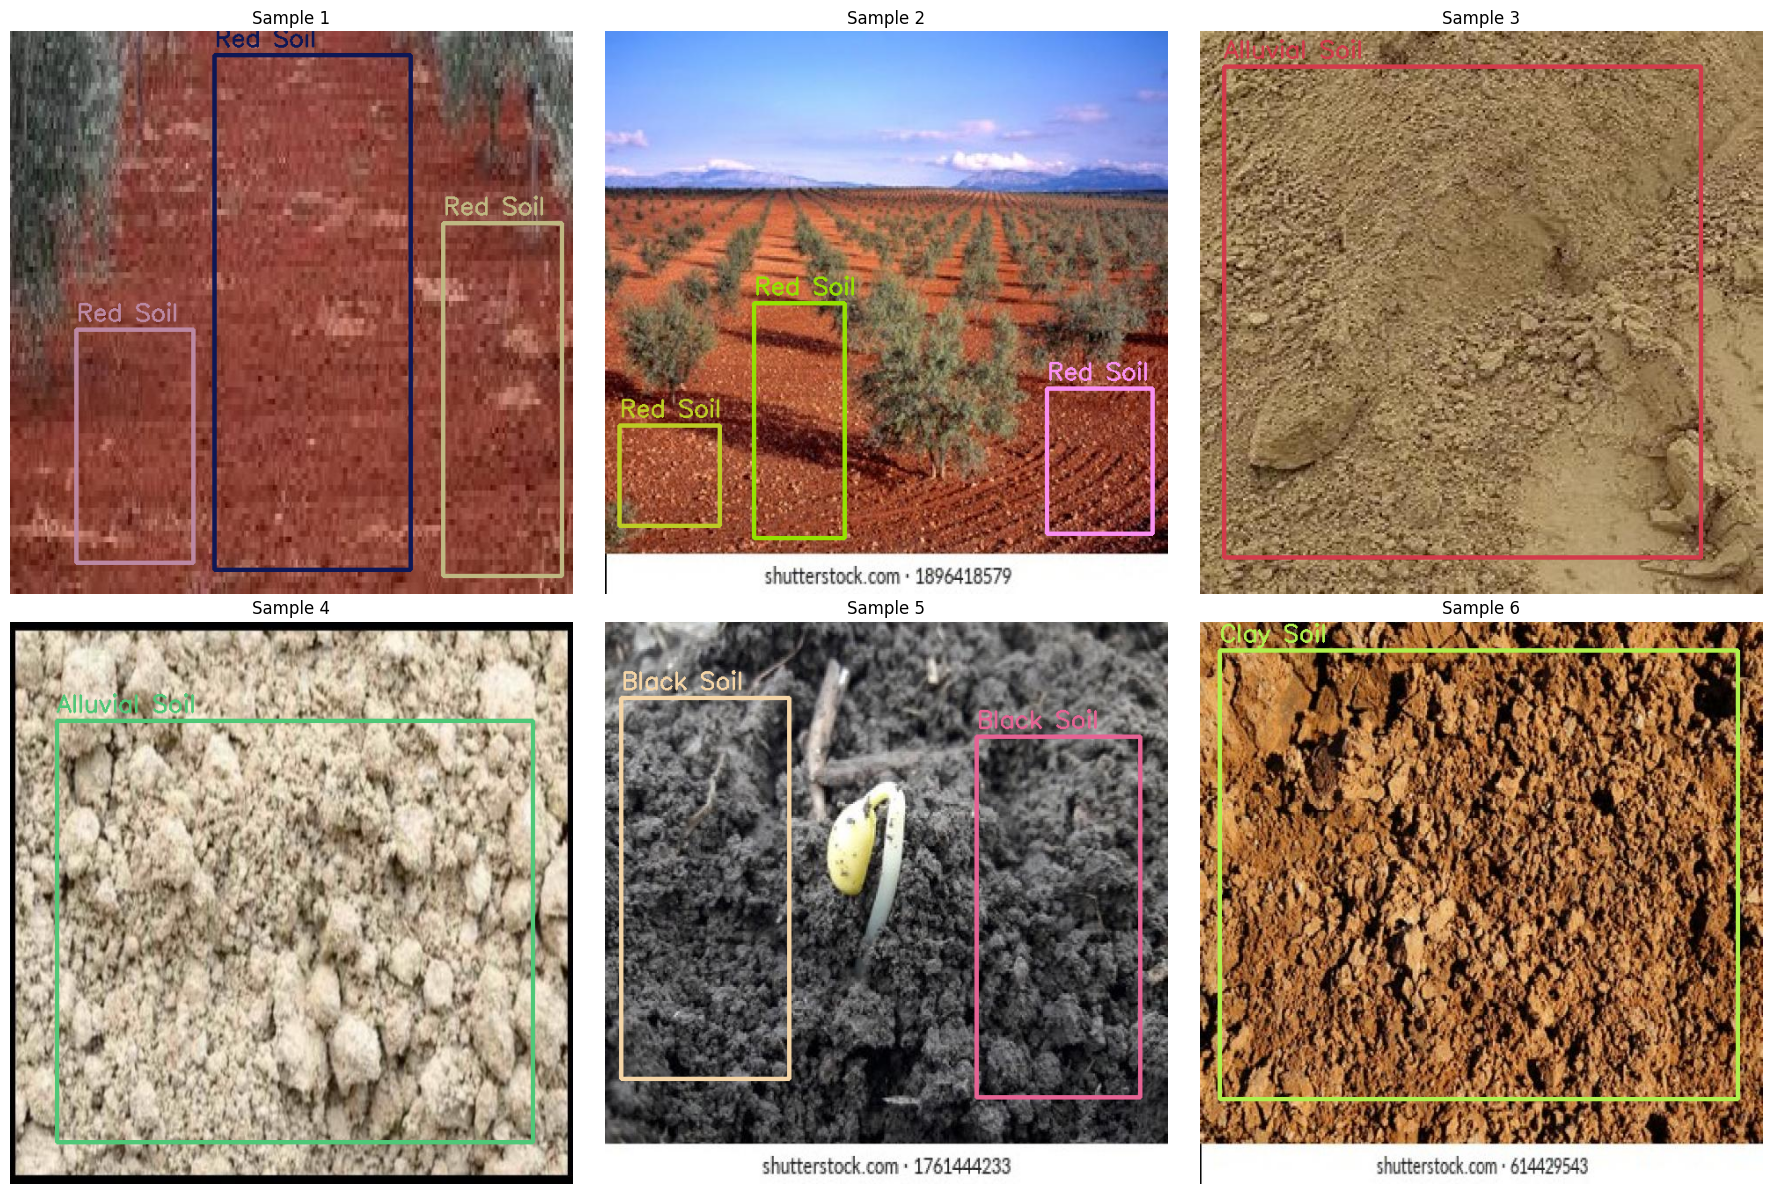

In [ ]:
def visualize_samples(data_path, class_names, num_samples=6):
    """Visualize sample images with bounding boxes"""
    img_path = Path(data_path) / 'images'
    lbl_path = Path(data_path) / 'labels'

    img_files = list(img_path.glob('*.jpg')) + list(img_path.glob('*.png'))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, img_file in enumerate(img_files[:num_samples]):
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_file = lbl_path / f"{img_file.stem}.txt"

        if lbl_file.exists():
            with open(lbl_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.strip():
                        parts = line.split()
                        class_id = int(parts[0])
                        x_center, y_center, width, height = map(float, parts[1:5])

                        # Convert YOLO format to pixel coordinates
                        x1 = int((x_center - width/2) * w)
                        y1 = int((y_center - height/2) * h)
                        x2 = int((x_center + width/2) * w)
                        y2 = int((y_center + height/2) * h)

                        # Draw bounding box
                        color = tuple(np.random.randint(0, 255, 3).tolist())
                        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                        # Add label
                        label = class_names[class_id]
                        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                                   0.9, color, 2)

        axes[idx].imshow(img)
        axes[idx].set_title(f"Sample {idx+1}")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('sample_annotations.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n=== Sample Images with Annotations ===")
visualize_samples(data_config['train'], SOIL_CLASSES)

Train YOLOv8 Model

In [ ]:
from ultralytics import YOLO
import torch

print("\n=== Training YOLOv8 Model ===")

# Check for GPU availability
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cpu':
    print("⚠️ WARNING: Training on CPU. This will be slower than GPU training.")
    print("Consider using Google Colab with GPU runtime for faster training.")

# Verify we have data before training
if train_imgs == 0:
    print("❌ ERROR: No training images found. Cannot train model.")
    print("Please check the dataset download and paths.")
else:
    # Initialize model
    model = YOLO('yolov8n.pt')  # Use nano model for faster training

    # Use the corrected YAML file
    yaml_file = str(corrected_yaml_path) if corrected_yaml_path.exists() else f"{dataset.location}/data.yaml"

    print(f"Using config file: {yaml_file}")

    # Train the model
    results = model.train(
        data=yaml_file,
        epochs=25,
        imgsz=640,
        batch=16 if device == 'cuda:0' else 8,  # Smaller batch for CPU
        name='soil_detection',
        patience=10,
        save=True,
        plots=True,
        device=device  # Use detected device
    )

    print("Training completed!")


=== Training YOLOv8 Model ===
Using device: cuda:0
Using config file: /content/Soil-detection-3/data_corrected.yaml
Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Soil-detection-3/data_corrected.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=soil_de

Regression Task

In [ ]:
print("\n=== Defining Regression Features and Target ===")

# 1. Initialize empty lists
features_X = []
target_y = []

# 2. Define soil_quality_weights dictionary
soil_quality_weights = {'Alluvial Soil': 0.8, 'Black Soil': 1.0, 'Clay Soil': 0.3, 'Red Soil': 0.5}

# 3. Iterate through each image in val_images (already defined from previous steps)
print(f"Processing {len(val_images)} validation images...")

for img_file in val_images:
    # 4a. Use the best_model.predict() method
    results = best_model.predict(str(img_file), conf=0.25, verbose=False)

    # 4b. Initialize dictionaries for class statistics
    class_counts = Counter() # Stores count of detections per class
    class_confidences = Counter() # Stores sum of confidence scores per class
    total_detections = 0

    # 4c. Iterate through the result.boxes from the predictions
    for result in results:
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                # i. Extract predicted class ID and confidence score
                pred_class_id = int(box.cls.item())
                confidence_score = box.conf.item()

                # ii. Update class_counts
                class_counts[pred_class_id] += 1
                # iii. Add confidence score to class_confidences
                class_confidences[pred_class_id] += confidence_score
                # iv. Increment total_detections
                total_detections += 1

    # 4d. Initialize image_features dictionary
    image_features = {}
    current_image_soil_quality_score = 0
    total_weighted_proportion = 0
    total_proportion = 0

    # 4e. For each soil class, calculate features
    for class_id, class_name in enumerate(SOIL_CLASSES):
        # i. Calculate the count of detections for the current class
        count = class_counts.get(class_id, 0)
        image_features[f'count_{class_name}'] = count

        # ii. Calculate the proportion of the current class
        proportion = count / total_detections if total_detections > 0 else 0
        image_features[f'proportion_{class_name}'] = proportion

        # iii. Calculate the average confidence for the current class
        avg_conf = class_confidences.get(class_id, 0) / count if count > 0 else 0
        image_features[f'avg_conf_{class_name}'] = avg_conf

        # Contribution to synthetic soil quality score
        if class_name in soil_quality_weights:
            total_weighted_proportion += proportion * soil_quality_weights[class_name]
            total_proportion += proportion

    # 4f. Calculate the soil_quality_score for the current image
    if total_proportion > 0:
        current_image_soil_quality_score = total_weighted_proportion / total_proportion
    else:
        current_image_soil_quality_score = 0 # No detections, score is 0

    # 4g. Append image_features to features_X and soil_quality_score to target_y
    features_X.append(image_features)
    target_y.append(current_image_soil_quality_score)

# 5. Convert features_X into a pandas DataFrame named X and target_y into a pandas Series named y
X = pd.DataFrame(features_X)
y = pd.Series(target_y, name='soil_quality_score')

print(f"Generated {len(X)} feature vectors and {len(y)} target scores.")
print("Features (X) head:")
print(X.head())
print("Target (y) head:")
print(y.head())


=== Defining Regression Features and Target ===
Processing 58 validation images...
Generated 58 feature vectors and 58 target scores.
Features (X) head:
   count_Alluvial Soil  proportion_Alluvial Soil  avg_conf_Alluvial Soil  \
0                    0                       0.0                     0.0   
1                    0                       0.0                     0.0   
2                    0                       0.0                     0.0   
3                    0                       0.0                     0.0   
4                    0                       0.0                     0.0   

   count_Black Soil  proportion_Black Soil  avg_conf_Black Soil  \
0                 0                    0.0             0.000000   
1                 1                    1.0             0.873542   
2                 0                    0.0             0.000000   
3                 1                    1.0             0.772719   
4                 0                    0.0            

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

print("\n=== Training Linear Regression Model ===")

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# 2. Instantiate a LinearRegression model
model_lr = LinearRegression()

# 3. Train the Linear Regression model
model_lr.fit(X_train, y_train)

print("Linear Regression model trained successfully!")


=== Training Linear Regression Model ===
Training set size: 46 samples
Testing set size: 12 samples
Linear Regression model trained successfully!



=== Evaluating Linear Regression Model ===
R-squared: 1.0000
Mean Squared Error (MSE): 0.0000
Mean Absolute Error (MAE): 0.0000


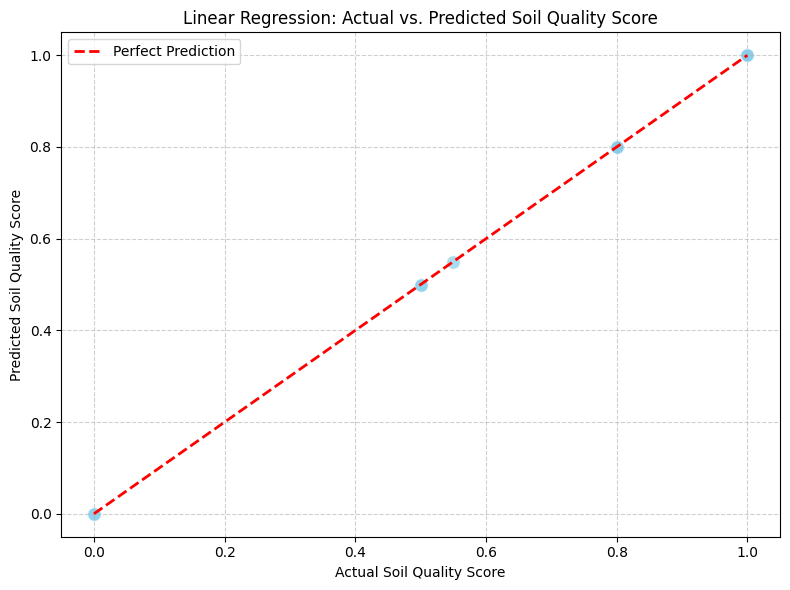

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n=== Evaluating Linear Regression Model ===")

# 1. Use the trained model_lr to make predictions on the X_test data.
y_pred_lr = model_lr.predict(X_test)

# 2. Calculate the R-squared score, Mean Squared Error (MSE), and Mean Absolute Error (MAE)
r_squared = r2_score(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)

# 3. Print the calculated metrics
print(f"R-squared: {r_squared:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# 4. Create a scatter plot with y_test on the x-axis and y_pred_lr on the y-axis
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.7, color='skyblue', edgecolors='w', s=100)

# Add a diagonal line representing perfect predictions
min_val = min(y_test.min(), y_pred_lr.min())
max_val = max(y_test.max(), y_pred_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# Label the x-axis as 'Actual Soil Quality Score' and the y-axis as 'Predicted Soil Quality Score'.
plt.xlabel('Actual Soil Quality Score')
plt.ylabel('Predicted Soil Quality Score')

# Add a title to the plot
plt.title('Linear Regression: Actual vs. Predicted Soil Quality Score')

# Add legend and grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot and save it to a file
plt.tight_layout()
plt.savefig('linear_regression_predictions.png', dpi=300, bbox_inches='tight')
plt.show()


XG Boost

In [ ]:
from xgboost import XGBRegressor

print("\n=== Training XGBoost Regression Model ===")

# Instantiate an XGBRegressor model with a random_state for reproducibility
# Using default parameters to start, can be tuned later if needed
model_xgb = XGBRegressor(random_state=42)

# Train the XGBoost model using the training data
model_xgb.fit(X_train, y_train)

print("XGBoost Regression model trained successfully!")


=== Training XGBoost Regression Model ===
XGBoost Regression model trained successfully!



=== Evaluating XGBoost Regression Model ===
XGBoost R-squared: 1.0000
XGBoost Mean Squared Error (MSE): 0.0000
XGBoost Mean Absolute Error (MAE): 0.0002


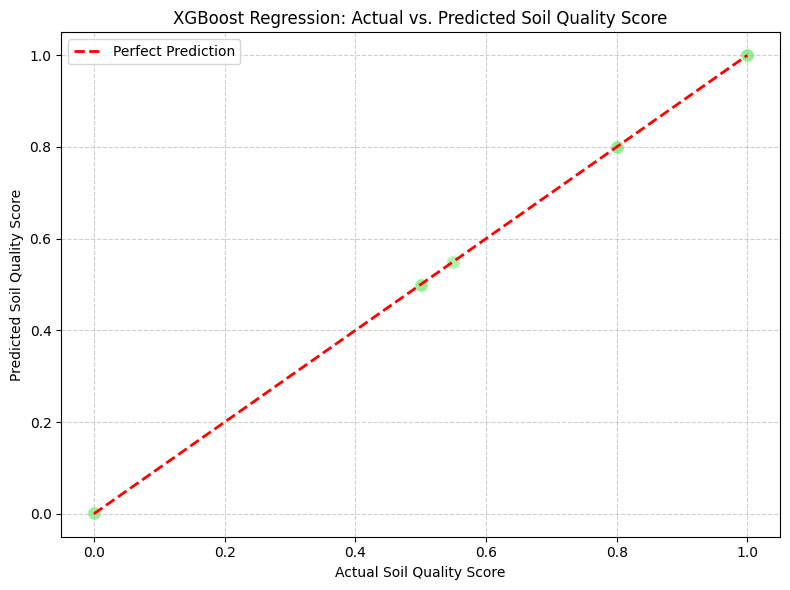

In [ ]:
print("\n=== Evaluating XGBoost Regression Model ===")

# 1. Use the trained model_xgb to make predictions on the X_test data.
y_pred_xgb = model_xgb.predict(X_test)

# 2. Calculate the R-squared score, Mean Squared Error (MSE), and Mean Absolute Error (MAE)
r_squared_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# 3. Print the calculated metrics
print(f"XGBoost R-squared: {r_squared_xgb:.4f}")
print(f"XGBoost Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"XGBoost Mean Absolute Error (MAE): {mae_xgb:.4f}")

# 4. Create a scatter plot with y_test on the x-axis and y_pred_xgb on the y-axis
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.7, color='lightgreen', edgecolors='w', s=100)

# Add a diagonal line representing perfect predictions
min_val_xgb = min(y_test.min(), y_pred_xgb.min())
max_val_xgb = max(y_test.max(), y_pred_xgb.max())
plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], 'r--', linewidth=2, label='Perfect Prediction')

# Label the x-axis as 'Actual Soil Quality Score' and the y-axis as 'Predicted Soil Quality Score'.
plt.xlabel('Actual Soil Quality Score')
plt.ylabel('Predicted Soil Quality Score')

# Add a title to the plot
plt.title('XGBoost Regression: Actual vs. Predicted Soil Quality Score')

# Add legend and grid
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot and save it to a file
plt.tight_layout()
plt.savefig('xgboost_regression_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print("\n=== Model Performance Comparison ===")

print("\n--- Linear Regression Metrics ---")
print(f"R-squared: {r_squared:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

print("\n--- XGBoost Regression Metrics ---")
print(f"R-squared: {r_squared_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")


=== Model Performance Comparison ===

--- Linear Regression Metrics ---
R-squared: 1.0000
Mean Squared Error (MSE): 0.0000
Mean Absolute Error (MAE): 0.0000

--- XGBoost Regression Metrics ---
R-squared: 1.0000
Mean Squared Error (MSE): 0.0000
Mean Absolute Error (MAE): 0.0002


Load Best Model and Validate

In [ ]:
print("\n=== Model Validation ===")

# Check if training was successful and model exists
model_path = Path('runs/detect/soil_detection/weights/best.pt')

if not model_path.exists():
    print("❌ ERROR: Trained model not found!")
    print(f"Expected location: {model_path}")
    print("\nPossible reasons:")
    print("1. Training cell (Cell 8) was not executed")
    print("2. Training failed or was interrupted")
    print("3. Model was saved to a different location")

    # Search for any trained models
    print("\nSearching for trained models...")
    runs_dir = Path('runs/detect')
    if runs_dir.exists():
        model_files = list(runs_dir.rglob('best.pt'))
        if model_files:
            print(f"Found {len(model_files)} trained model(s):")
            for mf in model_files:
                print(f"  - {mf}")
            print("\nUpdate the model_path variable to use one of these models.")
        else:
            print("No trained models found in runs/detect/")
    else:
        print("runs/detect/ directory not found. Training may not have started.")

    print("\n⚠️ Skipping validation. Please train the model first (Cell 8).")
    best_model = None
else:
    # Load best model
    best_model = YOLO(str(model_path))
    print(f"✅ Model loaded from: {model_path}")

    # Validate on validation set
    val_results = best_model.val(data=str(corrected_yaml_path) if corrected_yaml_path.exists() else f"{dataset.location}/data.yaml")

    print(f"\nValidation Results:")
    print(f"mAP50: {val_results.box.map50:.4f}")
    print(f"mAP50-95: {val_results.box.map:.4f}")
    print(f"Precision: {val_results.box.mp:.4f}")
    print(f"Recall: {val_results.box.mr:.4f}")


=== Model Validation ===
✅ Model loaded from: runs/detect/soil_detection/weights/best.pt
Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2058.0±374.4 MB/s, size: 86.4 KB)
val: Scanning /content/Soil-detection-3/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 117.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.2s
                   all         58         72      0.518      0.494      0.511       0.31
         Alluvial Soil         18         21      0.398      0.524      0.434      0.236
            Black Soil         17         21      0.841      0.758      0.858      0.532
             Clay Soil          9         11      0.467      0.273      0.345      0.228
              Red Soil         15         1

Generate Predictions and Confusion Matrix

In [ ]:
val_img_path = Path(data_config['val']) / 'images'
val_lbl_path = Path(data_config['val']) / 'labels'

# Get predictions
y_true = []
y_pred = []

val_images = list(val_img_path.glob('*.jpg')) + list(val_img_path.glob('*.png'))

for img_file in val_images[:100]:  # Process first 100 for speed
    # Get ground truth
    lbl_file = val_lbl_path / f"{img_file.stem}.txt"
    if lbl_file.exists():
        with open(lbl_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                if line.strip():
                    class_id = int(line.split()[0])
                    y_true.append(class_id)

    # Get predictions
    results = best_model.predict(str(img_file), verbose=False)
    for result in results:
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                pred_class = int(box.cls.item())
                y_pred.append(pred_class)

# Ensure equal length (simple approach - truncate to minimum)
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

Confusion Matrix Visualization

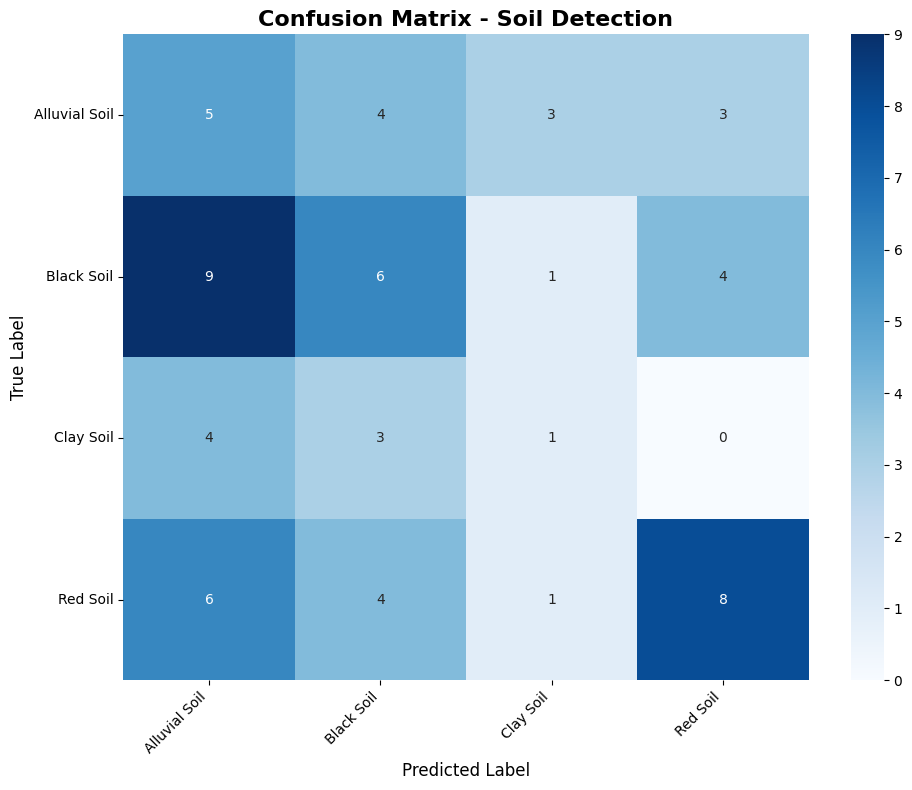


=== Classification Report ===
               precision    recall  f1-score   support

Alluvial Soil       0.21      0.33      0.26        15
   Black Soil       0.35      0.30      0.32        20
    Clay Soil       0.17      0.12      0.14         8
     Red Soil       0.53      0.42      0.47        19

     accuracy                           0.32        62
    macro avg       0.32      0.29      0.30        62
 weighted avg       0.35      0.32      0.33        62



In [ ]:
from sklearn.metrics import classification_report

if len(y_true) > 0 and len(y_pred) > 0:
    cm = confusion_matrix(y_true, y_pred, labels=range(len(SOIL_CLASSES)))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=SOIL_CLASSES,
                yticklabels=SOIL_CLASSES)
    plt.title('Confusion Matrix - Soil Detection', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=SOIL_CLASSES, zero_division=0))

Visualize Training Metrics

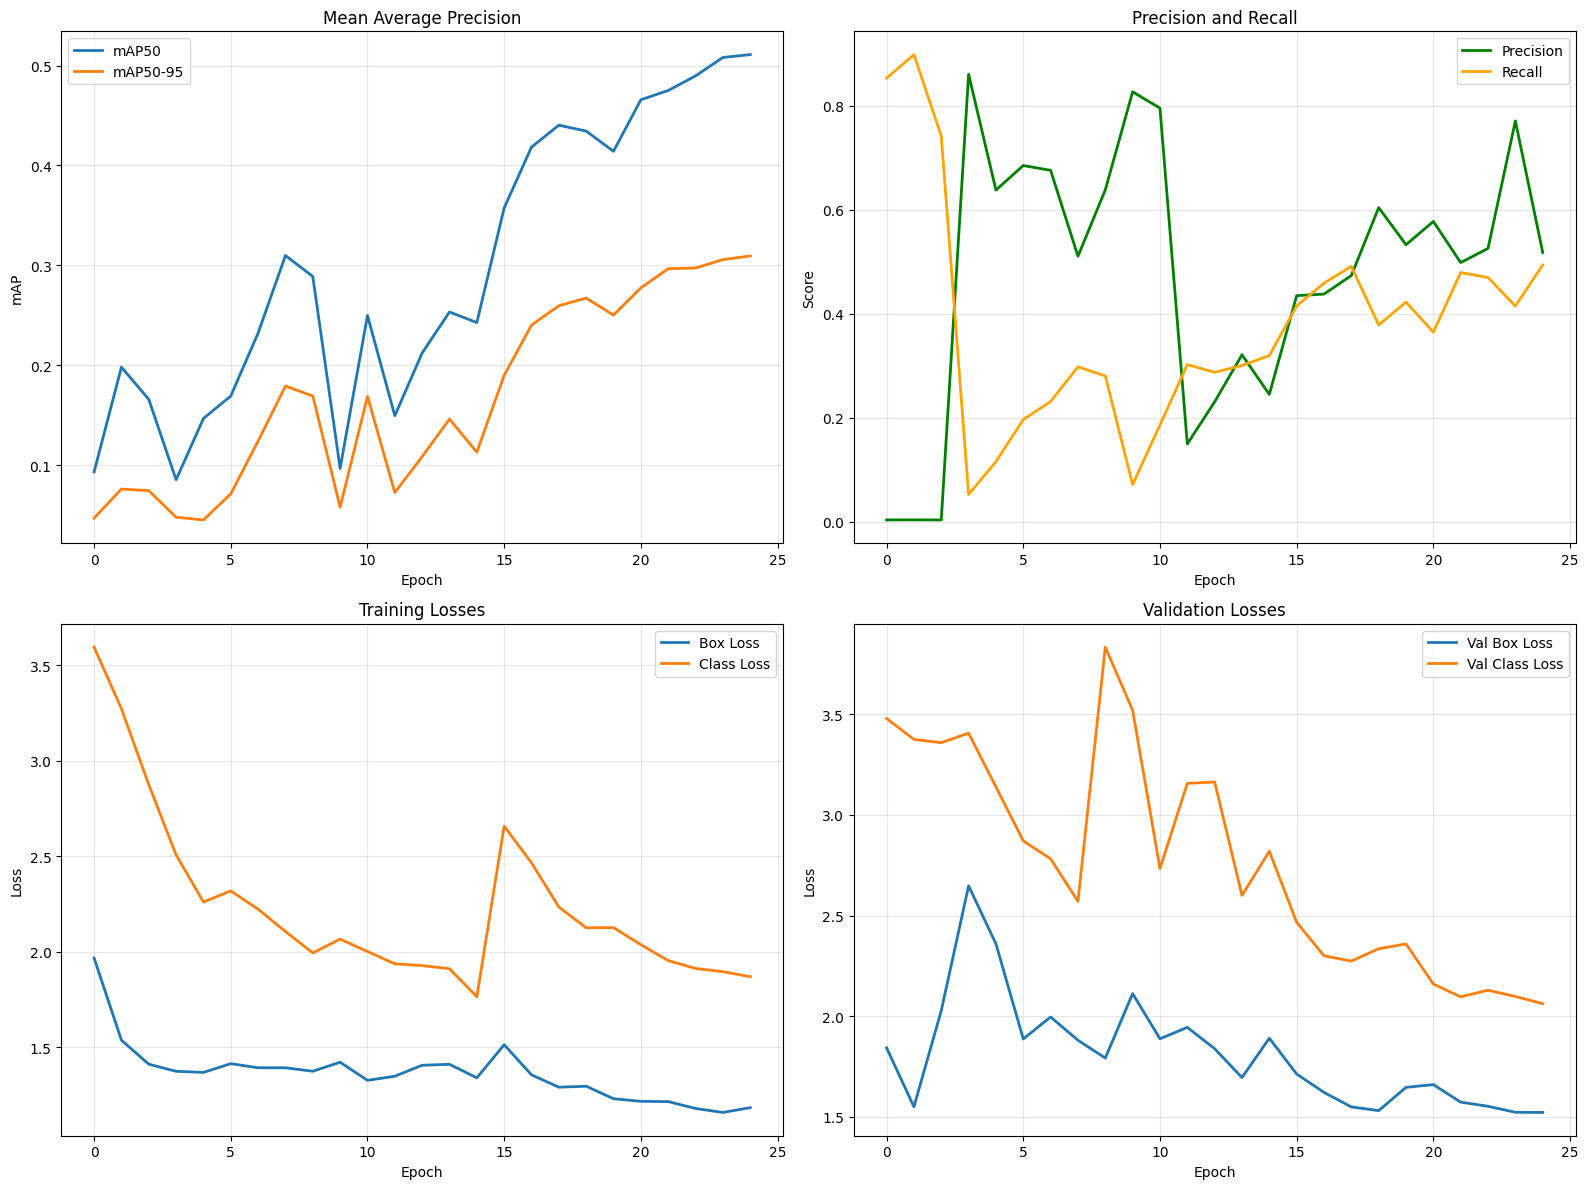

In [ ]:
results_dir = Path('runs/detect/soil_detection')

# Load and plot training results
if (results_dir / 'results.csv').exists():
    df_results = pd.read_csv(results_dir / 'results.csv')
    df_results.columns = df_results.columns.str.strip()

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot mAP
    if 'metrics/mAP50(B)' in df_results.columns:
        axes[0, 0].plot(df_results['metrics/mAP50(B)'], label='mAP50', linewidth=2)
        axes[0, 0].plot(df_results['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('mAP')
        axes[0, 0].set_title('Mean Average Precision')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

    # Plot Precision and Recall
    if 'metrics/precision(B)' in df_results.columns:
        axes[0, 1].plot(df_results['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
        axes[0, 1].plot(df_results['metrics/recall(B)'], label='Recall', linewidth=2, color='orange')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_title('Precision and Recall')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

    # Plot Losses
    if 'train/box_loss' in df_results.columns:
        axes[1, 0].plot(df_results['train/box_loss'], label='Box Loss', linewidth=2)
        axes[1, 0].plot(df_results['train/cls_loss'], label='Class Loss', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Training Losses')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

    # Plot Validation Loss
    if 'val/box_loss' in df_results.columns:
        axes[1, 1].plot(df_results['val/box_loss'], label='Val Box Loss', linewidth=2)
        axes[1, 1].plot(df_results['val/cls_loss'], label='Val Class Loss', linewidth=2)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Loss')
        axes[1, 1].set_title('Validation Losses')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

Test on Sample Images


=== Testing on Sample Images ===


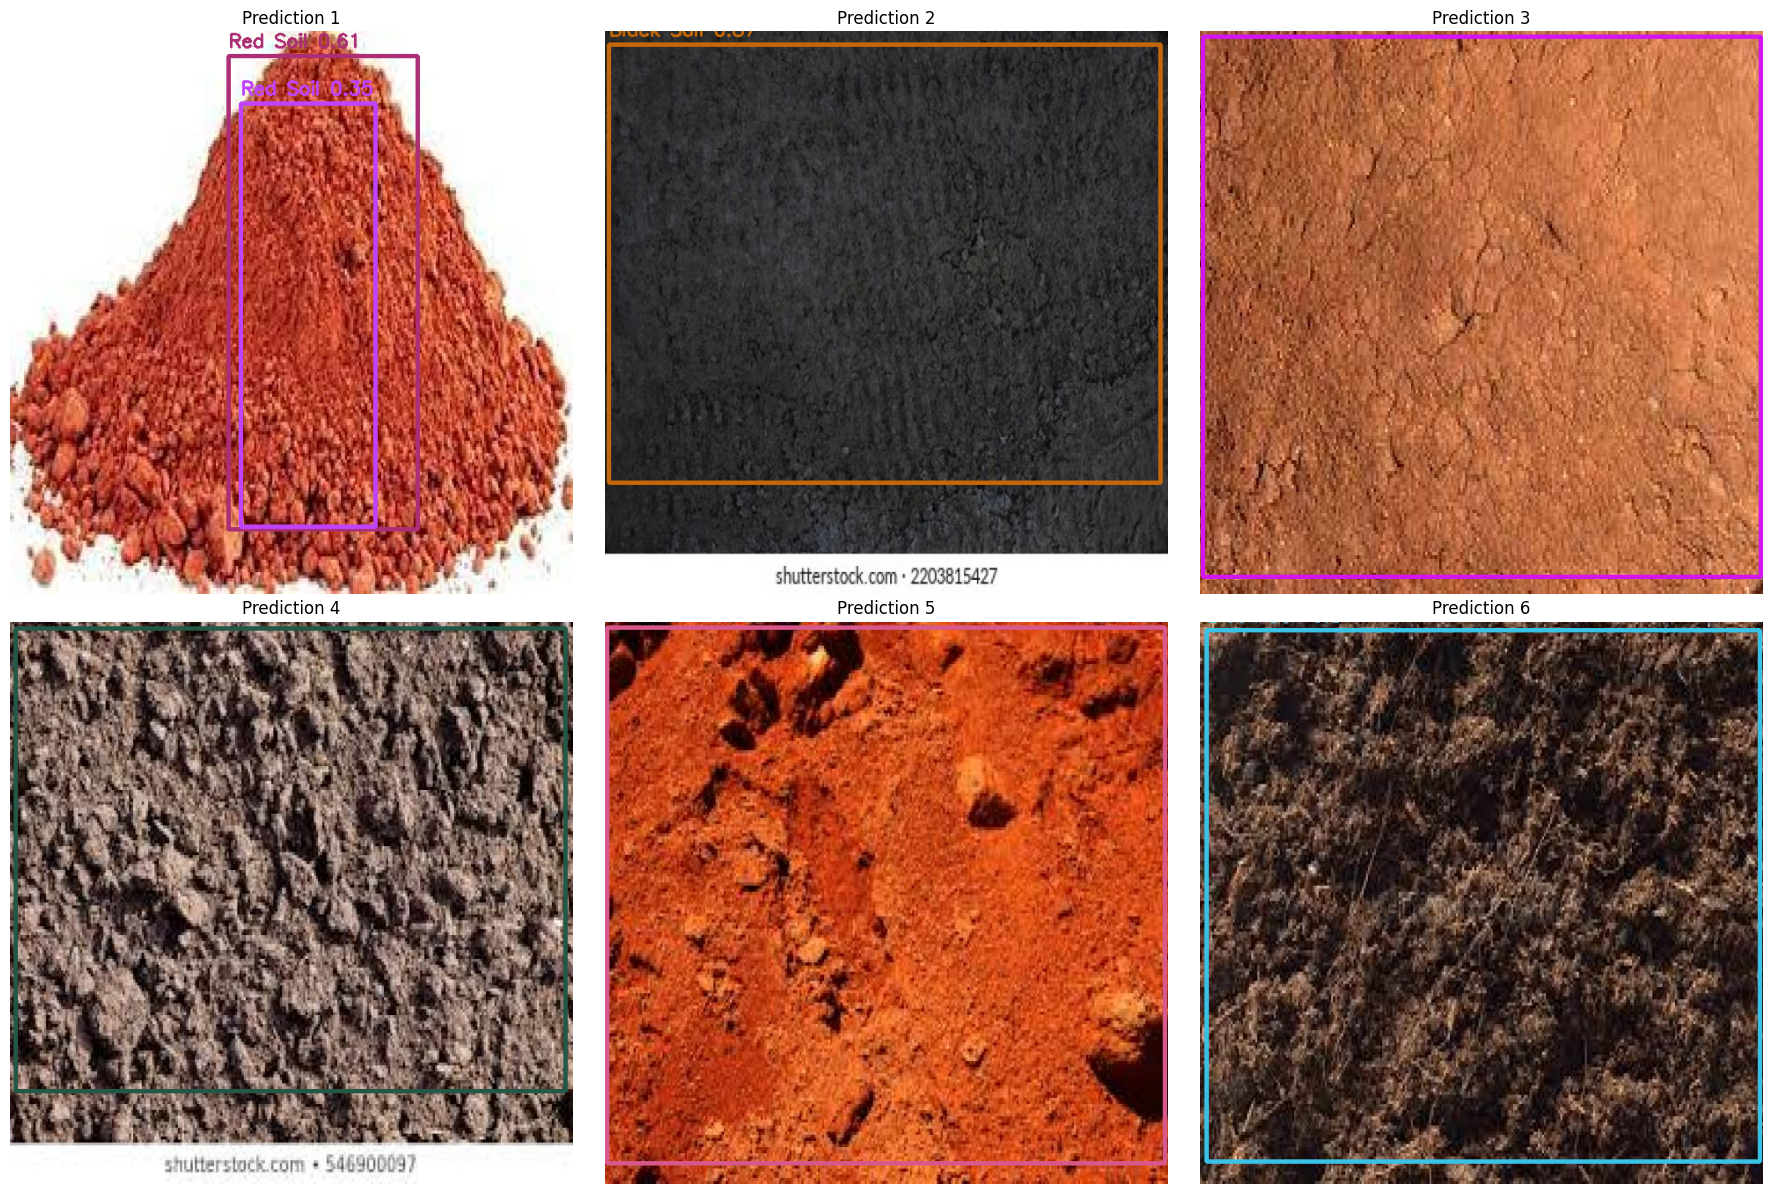

In [ ]:
print("\n=== Testing on Sample Images ===")

test_images = list(val_img_path.glob('*.jpg'))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_path in enumerate(test_images):
    results = best_model.predict(str(img_path), conf=0.25)

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw predictions
    for result in results:
        if result.boxes is not None:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = box.conf.item()
                cls = int(box.cls.item())

                color = tuple(np.random.randint(0, 255, 3).tolist())
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                label = f"{SOIL_CLASSES[cls]} {conf:.2f}"
                cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                           0.7, color, 2)

    axes[idx].imshow(img)
    axes[idx].set_title(f"Prediction {idx+1}")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

Save Model and Export Results

In [ ]:
print("\n=== Saving Model and Results ===")

# Export model
best_model.export(format='onnx')

# Save metrics
metrics_dict = {
    'mAP50': float(val_results.box.map50),
    'mAP50-95': float(val_results.box.map),
    'Precision': float(val_results.box.mp),
    'Recall': float(val_results.box.mr),
    'Classes': SOIL_CLASSES
}

with open('soil_detection_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)

print("Model saved successfully!")
print(f"Best weights: runs/detect/soil_detection/weights/best.pt")
print(f"ONNX model: runs/detect/soil_detection/weights/best.onnx")
print(f"Metrics saved to: soil_detection_metrics.json")

print("\n=== Soil Detection Training Complete ===")


=== Saving Model and Results ===
Ultralytics 8.3.246 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/soil_detection/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 8, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 195ms
Prepared 6 packages in 4.80s
Installed 6 packages in 251ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.0
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 5.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.0 opset 22...


Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 7.1s, saved as 'runs/detect/soil_detection/weights/best.onnx' (11.7 MB)

Export complete (7.5s)
Results saved to /content/runs/detect/soil_detection/weights
Predict:         yolo predict task=detect model=runs/detect/soil_detection/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=runs/detect/soil_detection/weights/best.onnx imgsz=640 data=/content/Soil-detection-3/data_corrected.yaml  
Visualize:       https://netron.app
Model saved successfully!
Best weights: runs/detect/soil_detection/weights/best.pt
ONNX model: runs/detect/soil_detection/weights/best.onnx
Metrics saved to: soil_detection_metrics.json

=== Soil Detection Training Complete ===


**Reasoning**:
The subtask is to create a new code cell for custom image prediction. I need to generate a `code_block` that defines a user input for the image path, loads the image, runs the trained model for prediction, draws bounding boxes and labels, and then displays the result.




=== Custom Image Prediction ===
Processing custom image: /content/samplesoil.jpeg


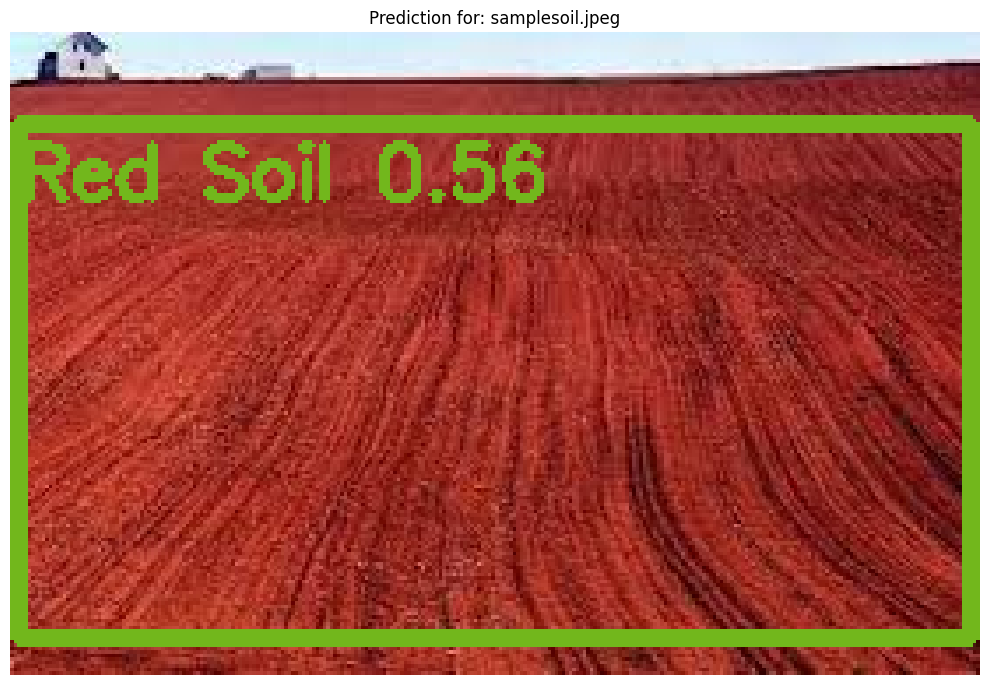

In [ ]:
print("\n=== Custom Image Prediction ===")

# 1. Define a variable custom_image_path using a Colab form
custom_image_path = '/content/samplesoil.jpeg' # @param {type:"string"}

# Check if best_model is available
if 'best_model' not in locals() or best_model is None:
    print("❌ ERROR: Model not loaded. Please ensure training (Cell 8) and model loading (Cell 9) were successful.")
else:
    # 2. Add a check to ensure custom_image_path is not empty and that the file exists
    if custom_image_path:
        user_img_path_obj = Path(custom_image_path)
        if user_img_path_obj.exists():
            print(f"Processing custom image: {user_img_path_obj}")

            # 3. If the path is valid, load the image
            img = cv2.imread(str(user_img_path_obj))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 4. Use the best_model.predict() method
            results = best_model.predict(str(user_img_path_obj), conf=0.25, verbose=False)

            # Create a figure to display the prediction
            plt.figure(figsize=(10, 10))

            # 5. Iterate through the prediction results
            for result in results:
                if result.boxes is not None:
                    for box in result.boxes:
                        x1, y1, x2, y2 = map(int, box.xyxy[0])
                        conf = box.conf.item()
                        cls = int(box.cls.item())

                        # 6. Draw bounding box and add label
                        color = tuple(np.random.randint(0, 255, 3).tolist()) # Random color for each box
                        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 3)

                        label = f"{SOIL_CLASSES[cls]} {conf:.2f}"
                        # Calculate text size to adjust position
                        (text_width, text_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
                        # Ensure label is above the box and visible
                        y_label = y1 - 10 if y1 - 10 > text_height else y1 + text_height + 5
                        x_label = x1 if x1 + text_width < img_rgb.shape[1] else img_rgb.shape[1] - text_width - 5

                        cv2.putText(img_rgb, label, (x_label, y_label), cv2.FONT_HERSHEY_SIMPLEX,
                                   0.7, color, 2)

            # 7. Display the image with predictions
            plt.imshow(img_rgb)
            plt.axis('off')
            # 8. Add a title to the plot
            plt.title(f"Prediction for: {user_img_path_obj.name}")
            plt.tight_layout()
            plt.show()
        else:
            print(f"❌ ERROR: Custom image path '{custom_image_path}' does not exist. Please provide a valid path.")
    else:
        print("ℹ️ No custom image path provided. To test with your own image, enter its path in the `custom_image_path` variable.")